# Does a background correction explain disk's weak averaging gain?

Follow-up on `test_bead_round_averaging.ipynb`
(`prompt_history/2026_09_02_1805_corner_vs_diagonal_residuals_and_bead_
averaging.md`): averaging aligned beads frames across rounds cut background
noise std to only 1.12x for `epi` (vs. the 3.16x `sqrt(10)` independent-noise
rounds would predict) and to 0.95x for `disk` -- **no improvement at all**
(vs. `sqrt(2)`=1.41x), with disk's own zoomed comparison figure showing a
visible fixed-pattern vertical striping/gradient in the background that
doesn't average out because it's identical in every round.

This notebook tests three corrections against that hypothesis:

1. **Local background subtraction** -- each frame minus its own heavily
   Gaussian-smoothed copy. Self-contained (one FOV, no other-FOV reads), but
   can only remove structure much coarser than its smoothing sigma.
2. **Multi-FOV flat-field correction (FFC), divide** -- `MERci.analysis.ffc`'s
   own illumination-field estimator, computed from **all** FOVs of the cells
   round (476 for `epi`, 603 for `disk`), the same technique already used
   for round mosaics elsewhere in this repo. Averaging over hundreds of FOVs
   should isolate the microscope's actual fixed vignetting field from any
   one FOV's own real bead/tissue signal, in principle correcting finer
   structure than option 1 can reach. The field is normalized to a `[0,1]`-ish
   peak and divided out: `NEW IMAGE = RAW IMAGE / FFC` -- the right model for
   inhomogeneous illumination and objective aberration, both multiplicative.
3. **Multi-FOV background correction (BGC), subtract** -- the same all-FOV
   averaging as #2, but with no Gaussian smoothing and no `[0,1]`
   normalization: a plain per-pixel mean across every FOV, kept in the
   camera's own raw intensity units. Appropriate when what's actually being
   estimated is closer to the camera/sensor's own fixed background level
   (dark current, per-column readout offset) than to optical vignetting --
   an additive, not multiplicative, effect: `NEW IMAGE = RAW IMAGE - BGC`,
   with the (expected) negative pixels clipped to zero.

**Characterized first, not assumed** (Section 4): FFT of the row-mean and
column-mean profiles of each dataset's own round-1 beads frame.
`disk`'s frame has a low mean/std (103 / 6.9 -- close to the camera's dark
level, i.e. genuinely low bead signal) and its column-mean profile is
dominated by a single smooth, low-frequency gradient (period on the order of
the full frame, not fine per-line banding), with the modulation a large
fraction (~28%) of the frame's own mean. `epi`'s frame has a far higher
mean/std (5637 / 8065) where the dominant row/column-mean structure is real
bead signal, not a background gradient. This is why the hypothesis expects a
correction to matter for `disk` but not `epi` -- confirmed or refuted with
real numbers in Section 8, not assumed from the characterization alone.

**Prior result, local background subtraction alone (kept for context, not
re-derived)**: `epi` unaffected (1.122x -> 1.121x, as predicted); `disk`
improved but only partially (0.954x -> 1.025x, still well short of 1.414x)
-- the coarse gradient was removed cleanly, but a finer vertical striping
pattern, too fine for that correction's smoothing scale, persisted and
stayed round-invariant. This notebook adds the multi-FOV FFC pipeline to
check whether it reaches further into that residual structure.

Reuses `test_bead_round_averaging.ipynb`'s own dataset-resolution,
FiducialCorrelationWarp-offset mapping, and round1-vs-average pipeline
(kept self-contained here, same convention as that notebook relative to
`test_stitching.ipynb`), with both correction steps applied to each round's
raw beads frame before alignment (both are fixed properties of the
camera/optics in camera-pixel coordinates, not the sample, and the per-round
alignment shift is at most a few px -- verified in
`test_bead_round_averaging.ipynb` -- so applying either correction before or
after the shift makes negligible difference here).

**Result with both corrections Gaussian-smoothed at `sigma_px=50`** (kept for
context, not re-derived): local bg-correction and the smoothed all-FOV FFC
converged to nearly the same partial result for `disk` (1.025x, 1.027x vs.
1.414x ideal) -- evidence the residual striping is *finer* than that shared
smoothing scale, not that the FFC sample was too small. This raises the
opposite question: is the `sigma_px=50` smoothing itself throwing away the
fine-grained fixed-pattern structure the FFC field should otherwise capture?
Averaged bead positions are effectively random per FOV, so a smooth
(low-pass) FFC field is the right estimate for *that* signal -- but the
sensor's own fixed-pattern column noise is deterministic and identical
every FOV, so it survives averaging over hundreds of FOVs undestroyed, and
should show up directly in the raw (unsmoothed) per-pixel average -- Section
5 below now also computes that unsmoothed field (`smooth_sigma_px=0`, a
no-op confirmed via `gaussian_filter(field, sigma=0.0)` returning the input
unchanged) as a fourth `ffc_raw_corrected` pipeline, to test whether skipping
the smoothing step recovers more of the averaging benefit than either
existing correction.

**Correction, this run**: the previous run's `ffc_raw_corrected` (unsmoothed
field, still divided out) is **kept unchanged, for comparison** -- it is not
the right model on reflection, since a divide-based correction only makes
sense for a multiplicative field normalized to a ~1.0 peak, and what the raw
(unsmoothed) all-FOV average is actually estimating for `disk` looks closer
to the camera/sensor's own fixed background pattern (dark current, per-
column readout offset) than to the smooth optical vignetting the *smoothed*
FFC field targets. Section 5 below now additionally computes a `BGC` field
per dataset -- the same all-FOV average, but with no Gaussian smoothing and
no post-hoc `[0,1]` normalization, kept in the camera's own real intensity
units -- and Section 6 adds a fifth pipeline, `bgc_subtracted`, that applies
it by subtraction (`NEW IMAGE = RAW IMAGE - BGC`, negative pixels clipped to
zero) rather than division. This also sidesteps the prior run's visual-
saturation artifact in the raw-FFC display panels (`prompt_history/
2026_09_02_1919_ffc_no_smoothing_variant.md`), which traced to
`normalize_percentile=99.99` -- tuned for a smoothed field -- being applied
to that same low-SNR unsmoothed field: `BGC` has no such normalization step
at all.

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import shift as ndi_shift, gaussian_filter

MERCI_DIR = Path(os.getcwd()).parent.parent.parent   # MERci/

sys.path.insert(0, str(MERCI_DIR / "src"))

from MERci.common.config          import ExperimentConfig
from MERci.common.metadata        import ExperimentMetadata
from MERci.common.io              import load_positions, read_image_frames
from MERci.common.experiment_info import load_experiment_info, resolve_sample_identity, positions_file_tag
from MERci.acquisition.configs    import get_camera_pixel_size_um
from MERci.acquisition.alignment  import remove_hot_pixels, phase_drift
from MERci.analysis.ffc           import compute_ffc_field_for_color, apply_ffc, save_ffc_field, load_ffc_field

NOTEBOOK_NAME = "test_bead_background_correction"
print(f"MERCI_DIR : {MERCI_DIR}")

MERCI_DIR : /n/home06/lsepulvedaduran/251225_LT027_saving_time/MERci


## 2 — Parameters

In [2]:
# Same two real BC555_sample_05 datasets as test_bead_round_averaging.ipynb.
DATASETS = [
    ("epi",  "/n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi"),
    ("disk", "/n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/disk"),
]

IMAGE_SUFFIX = ".zarr"
BEAD_FRAME_INDEX = 0
ROUND_TYPES_TO_USE = ("cells", "bits")

# Local-background estimate = a heavily Gaussian-smoothed copy of the frame
# itself. sigma_px=50 matches MERci.analysis.ffc.compute_ffc_field_for_color's
# own default smooth_sigma_px -- same repo convention for "large enough to
# average out bead spots (a few px), small enough to still track a
# few-hundred-px-scale gradient". The FFC field below reuses this same
# default via compute_ffc_field_for_color's own defaults, so both
# corrections share the same smoothing scale.
BG_SIGMA_PX = 50.0

FORCE_RECOMPUTE = False

PLOT_TITLE_FONTSIZE  = 14
PLOT_LABEL_FONTSIZE  = 12
PLOT_TICK_FONTSIZE   = 11
PLOT_LEGEND_FONTSIZE = 10

print(f"Datasets to analyze: {[label for label, _ in DATASETS]}  |  BG_SIGMA_PX={BG_SIGMA_PX}")

Datasets to analyze: ['epi', 'disk']  |  BG_SIGMA_PX=50.0


## 3 — Resolve dataset geometry + pick one representative FOV

Identical to `test_bead_round_averaging.ipynb` Section 3.

In [3]:
def resolve_dataset_geometry(dataset_label, dataset_dir):
    sample_dir = Path(dataset_dir)
    sample_name, imaging_dir = resolve_sample_identity(sample_dir / "MERci")
    positions_tag = positions_file_tag(sample_name, imaging_dir)

    info       = load_experiment_info(sample_dir / "metadata" / "experiment_info.yaml")
    microscope = info.microscope

    config = ExperimentConfig(
        data_dir       = sample_dir / "data",
        metadata_dir   = sample_dir / "metadata",
        analysis_dir   = sample_dir / "analysis",
        settings_dir   = sample_dir / "settings",
        round_info_csv = sample_dir / "metadata" / "round_info.csv",
        positions_txt  = sample_dir / "positions" / f"positions_{positions_tag}.txt",
        image_suffix   = IMAGE_SUFFIX,
        microscope     = microscope,
    )
    meta = ExperimentMetadata.load(config.round_info_csv, config.positions_txt, config.data_dir,
                                    image_suffix=config.image_suffix)

    full_positions = load_positions(config.positions_txt)
    pixel_size_um  = get_camera_pixel_size_um(microscope)

    round_ids = []
    for rid in meta.valid_round_ids():
        series = meta.series_for_round(rid)
        if series and (series[0].imaging_type or "").strip().lower() in ROUND_TYPES_TO_USE:
            round_ids.append(rid)
    round_ids.sort()
    cells_round_id = next(rid for rid in round_ids
                           if meta.series_for_round(rid)[0].imaging_type.strip().lower() == "cells")
    bits_round_ids = [rid for rid in round_ids if rid != cells_round_id]

    cells_fov_ids = sorted(meta.fovs)
    coords_arr = np.array([full_positions[f] for f in cells_fov_ids], dtype=float)
    centroid   = coords_arr.mean(axis=0)
    dist       = np.hypot(coords_arr[:, 0] - centroid[0], coords_arr[:, 1] - centroid[1])
    for fov_id in [cells_fov_ids[i] for i in np.argsort(dist)]:
        if all(meta.series_for_round(rid)[0].resolve_path(fov_id, config.image_suffix).exists()
               for rid in round_ids):
            representative_fov = fov_id
            break
    else:
        raise RuntimeError(f"[{dataset_label}] No FOV has on-disk data for every round in {round_ids}")

    figures_dir = config.analysis_dir / "figures"
    figures_dir.mkdir(parents=True, exist_ok=True)

    print(f"[{dataset_label}] SAMPLE_DIR        : {sample_dir}")
    print(f"[{dataset_label}] MICROSCOPE        : {microscope}")
    print(f"[{dataset_label}] Rounds used       : {round_ids}  (cells={cells_round_id}, bits={bits_round_ids})")
    print(f"[{dataset_label}] Representative FOV: {representative_fov}  (closest-to-centroid with full data)")
    print(f"[{dataset_label}] Total FOVs (cells round): {len(cells_fov_ids)}")

    return {
        "dataset_label": dataset_label, "sample_dir": sample_dir, "sample_name": sample_name,
        "microscope": microscope, "config": config, "meta": meta,
        "pixel_size_um": pixel_size_um, "cells_round_id": cells_round_id, "bits_round_ids": bits_round_ids,
        "round_ids": round_ids, "representative_fov": representative_fov, "figures_dir": figures_dir,
        "all_fov_ids": cells_fov_ids,
    }

## 4 — Characterize the background: is it a smooth gradient?

Row-mean and column-mean profiles of round 1's own beads frame, plus an FFT
of each profile to find the dominant spatial period. A slow, few-cycle
period (large fraction of the frame width) is consistent with an
illumination/vignette gradient; a period of a few px would instead point to
per-line sensor/readout banding, which a large-sigma blur would NOT
correctly model as background.

In [4]:
def characterize_background(dataset_geo):
    label, meta, config = dataset_geo["dataset_label"], dataset_geo["meta"], dataset_geo["config"]
    fov_id, cells_round_id = dataset_geo["representative_fov"], dataset_geo["cells_round_id"]
    series = meta.series_for_round(cells_round_id)[0]
    path = series.resolve_path(fov_id, config.image_suffix)
    frame = read_image_frames(path, [BEAD_FRAME_INDEX],
                               frame_width=config.frame_width, frame_height=config.frame_height)[0].astype(float)

    row_mean, col_mean = frame.mean(axis=1), frame.mean(axis=0)

    def top_period(profile):
        detrended = profile - profile.mean()
        fft = np.abs(np.fft.rfft(detrended))
        freqs = np.fft.rfftfreq(len(detrended))
        i = np.argmax(fft[1:]) + 1   # skip DC
        return (1 / freqs[i]) if freqs[i] > 0 else np.inf

    print(f"[{label}] frame mean={frame.mean():.1f}  std={frame.std():.1f}")
    print(f"[{label}] row_mean range=({row_mean.min():.1f},{row_mean.max():.1f})"
          f"  dominant period={top_period(row_mean):.0f} px  (frame height={frame.shape[0]})")
    print(f"[{label}] col_mean range=({col_mean.min():.1f},{col_mean.max():.1f})"
          f"  dominant period={top_period(col_mean):.0f} px  (frame width={frame.shape[1]})")
    return frame, row_mean, col_mean

[epi] SAMPLE_DIR        : /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi
[epi] MICROSCOPE        : MF3
[epi] Rounds used       : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]  (cells=1, bits=[2, 3, 4, 5, 6, 7, 8, 9, 10])
[epi] Representative FOV: 221  (closest-to-centroid with full data)
[epi] Total FOVs (cells round): 476


[epi] frame mean=5636.6  std=8064.5
[epi] row_mean range=(3306.7,8062.9)  dominant period=2048 px  (frame height=2048)
[epi] col_mean range=(1728.3,9763.9)  dominant period=2048 px  (frame width=2048)


[disk] SAMPLE_DIR        : /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/disk
[disk] MICROSCOPE        : ST2
[disk] Rounds used       : [1, 2]  (cells=1, bits=[2])
[disk] Representative FOV: 301  (closest-to-centroid with full data)
[disk] Total FOVs (cells round): 603
[disk] frame mean=103.4  std=6.9
[disk] row_mean range=(100.4,109.1)  dominant period=2304 px  (frame height=2304)
[disk] col_mean range=(93.9,123.1)  dominant period=1152 px  (frame width=2304)


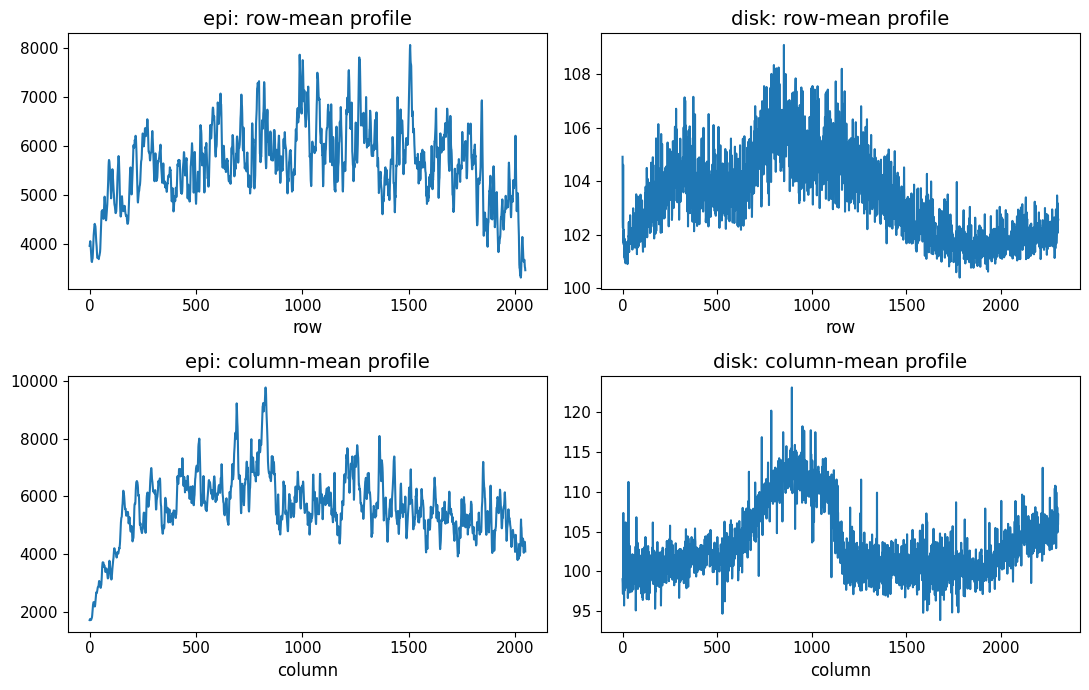

Saved: /n/home06/lsepulvedaduran/251225_LT027_saving_time/MERci/cache/test_bead_background_correction_comparison/test_bead_background_correction.background_profiles.png


In [5]:
BG_CHARACTERIZATION = {}
for dataset_label, dataset_dir in DATASETS:
    dataset_geo = resolve_dataset_geometry(dataset_label, dataset_dir)
    frame, row_mean, col_mean = characterize_background(dataset_geo)
    BG_CHARACTERIZATION[dataset_label] = {
        "dataset_geo": dataset_geo, "frame": frame, "row_mean": row_mean, "col_mean": col_mean,
    }

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for col, (dataset_label, C) in enumerate(BG_CHARACTERIZATION.items()):
    axes[0, col].plot(C["row_mean"])
    axes[0, col].set_title(f"{dataset_label}: row-mean profile", fontsize=PLOT_TITLE_FONTSIZE)
    axes[0, col].set_xlabel("row", fontsize=PLOT_LABEL_FONTSIZE)
    axes[1, col].plot(C["col_mean"])
    axes[1, col].set_title(f"{dataset_label}: column-mean profile", fontsize=PLOT_TITLE_FONTSIZE)
    axes[1, col].set_xlabel("column", fontsize=PLOT_LABEL_FONTSIZE)
    for ax in (axes[0, col], axes[1, col]):
        ax.tick_params(axis="both", labelsize=PLOT_TICK_FONTSIZE)
fig.tight_layout()
fig_path = MERCI_DIR / "cache" / "test_bead_background_correction_comparison" / f"{NOTEBOOK_NAME}.background_profiles.png"
fig_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(fig_path, dpi=150)
plt.show()
print(f"Saved: {fig_path}")

## 5 — Multi-FOV fields, computed from ALL FOVs: FFC (divide) + BGC (subtract)

`MERci.analysis.ffc.compute_ffc_field_for_color` accumulates a running mean
over every sample, optionally Gaussian-smooths it, then normalizes to ~1.0
peak -- its own docstring's `"single_fov_all_frames"`/`"exterior_grid"`/
`"emptiest_stats"` strategies are for *online*, mid-acquisition use when
not every FOV is available yet; here, post-hoc with the full dataset on
disk, we use literally **every** FOV of the cells round (one sample per FOV,
`BEAD_FRAME_INDEX`) -- 476 for `epi`, 603 for `disk` -- so real bead/tissue
signal, which varies per FOV, averages out far more thoroughly than any
FOV-subset strategy, leaving a cleaner estimate of the vignetting each pixel
location experiences regardless of FOV.

Three fields per dataset, from the *same* per-FOV samples:

- **FFC, `smooth_sigma_px=50.0`** (the function's own default) -- the field
  used in the original run of this notebook. Divided out (Section 6).
- **FFC, `smooth_sigma_px=0.0`** -- a no-op for `gaussian_filter` (verified:
  an all-zero-sigma call returns its input unchanged), so this is the raw
  per-pixel average across FOVs, un-smoothed, still normalized to ~1.0 peak
  and divided out (Section 6) -- kept unchanged from the prior run, for
  comparison against the subtractive model below.
- **BGC, no smoothing, no normalization** -- the same raw per-pixel average,
  but kept in the camera's own real intensity units (no Gaussian smoothing,
  no `[0,1]` rescaling). A fixed-pattern sensor artifact (e.g. per-column
  readout noise) is identical in every FOV, so it survives averaging over
  hundreds of FOVs fully intact and shows up directly in this field -- but
  it is additive (a camera background level), not multiplicative, so it is
  *subtracted*, not divided out (Section 6).

Field display ranges below are fixed, not auto-scaled: FFC fields (both
sigmas) at `[0, 1]` -- their expected normalized range -- and `disk`'s BGC
field at `[0, 150]`, matching the ~103±7 dark-level mean/std found for
`disk` in Section 4. `epi`'s BGC field is left auto-scaled (its background
is real bead signal at a much higher intensity, not a dark-level pattern --
Section 4).

One field triple per dataset, computed once from the cells round and reused
for every round's beads frame -- vignetting/background level is a fixed
property of the microscope/channel, not of round (`ffc.py`'s own stated
assumption for FFC; the same holds for BGC). Cached (`~2-3 min` to compute
per dataset from ~500 FOV reads;
`~/analysis/cache/test_bead_background_correction/{ffc,bgc}_field*.npz`).

[epi] Loaded cached FFC field (sigma=50.0, 476 samples): /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi/analysis/cache/test_bead_background_correction/ffc_field.npz
[epi] Loaded cached FFC field (sigma=0.0, 476 samples): /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi/analysis/cache/test_bead_background_correction/ffc_field_raw.npz
[epi] Computing BGC field (raw mean, no smoothing) from 476 FOVs (cells round 1)...


[epi] BGC field computed from 476 FOVs and cached: /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi/analysis/cache/test_bead_background_correction/bgc_field.npz


[disk] Loaded cached FFC field (sigma=50.0, 603 samples): /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/disk/analysis/cache/test_bead_background_correction/ffc_field.npz


[disk] Loaded cached FFC field (sigma=0.0, 603 samples): /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/disk/analysis/cache/test_bead_background_correction/ffc_field_raw.npz
[disk] Computing BGC field (raw mean, no smoothing) from 603 FOVs (cells round 1)...


[disk] BGC field computed from 603 FOVs and cached: /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/disk/analysis/cache/test_bead_background_correction/bgc_field.npz


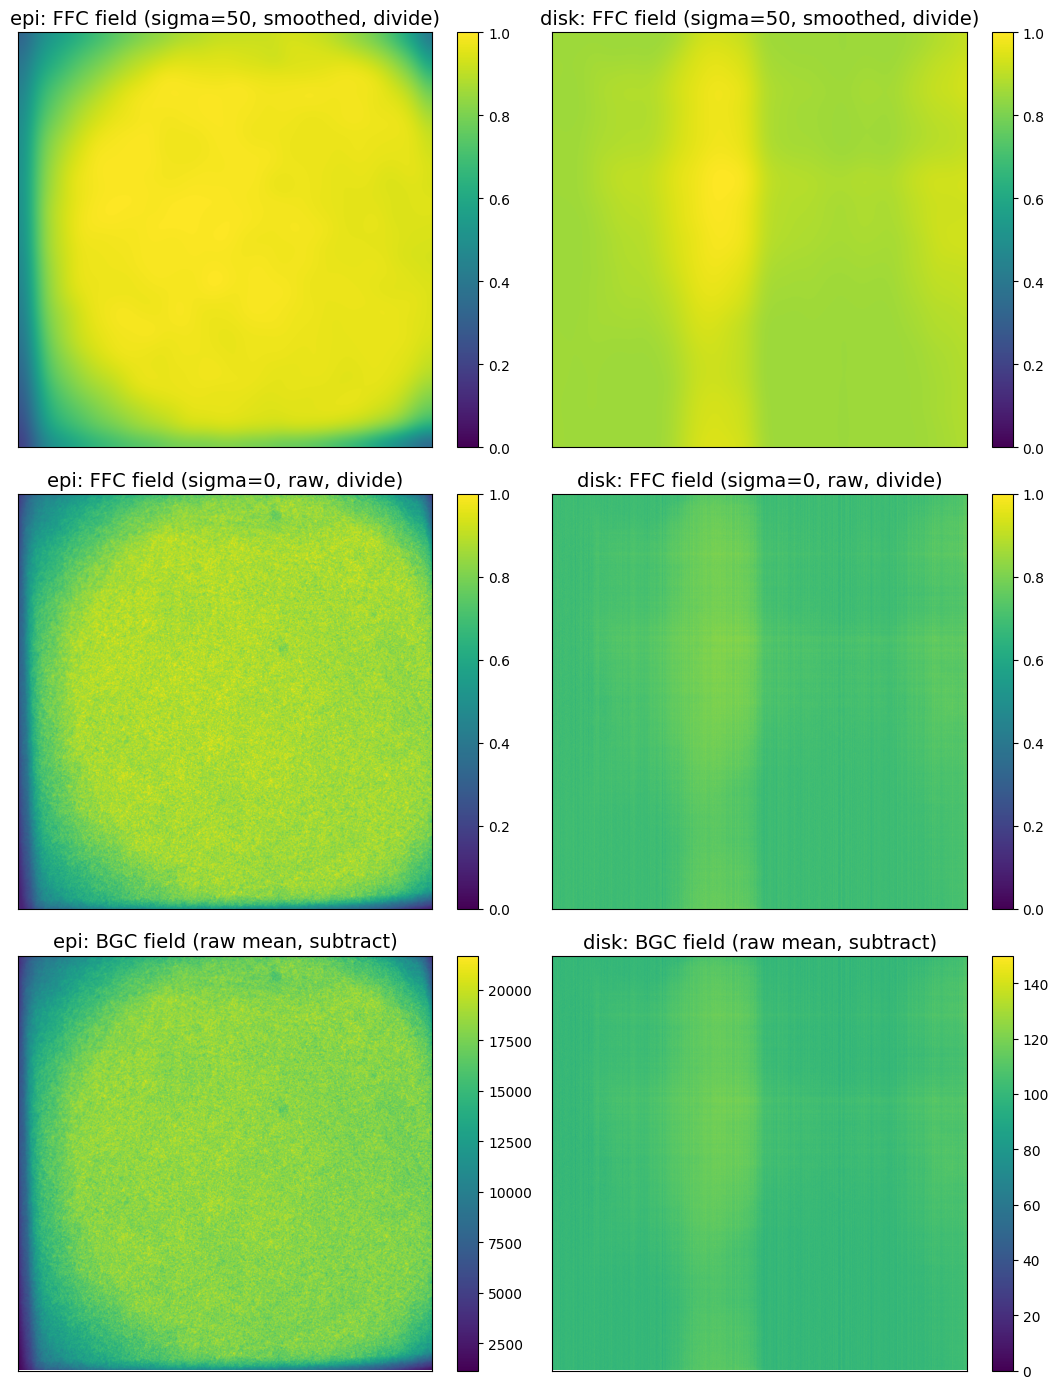

Saved: /n/home06/lsepulvedaduran/251225_LT027_saving_time/MERci/cache/test_bead_background_correction_comparison/test_bead_background_correction.ffc_fields.png


In [6]:
def resolve_cells_round_samples(dataset_geo):
    config, meta = dataset_geo["config"], dataset_geo["meta"]
    series = meta.series_for_round(dataset_geo["cells_round_id"])[0]
    return [(series.resolve_path(fov_id, config.image_suffix), BEAD_FRAME_INDEX)
            for fov_id in dataset_geo["all_fov_ids"]
            if series.resolve_path(fov_id, config.image_suffix).exists()]


def compute_dataset_ffc_field(dataset_geo, smooth_sigma_px, cache_name):
    label, config = dataset_geo["dataset_label"], dataset_geo["config"]
    cache_path = config.analysis_dir / "cache" / NOTEBOOK_NAME / cache_name

    if not FORCE_RECOMPUTE and cache_path.exists():
        field, field_meta = load_ffc_field(cache_path)
        print(f"[{label}] Loaded cached FFC field (sigma={smooth_sigma_px}, "
              f"{int(field_meta.get('n_samples', -1))} samples): {cache_path}")
        return field

    samples = resolve_cells_round_samples(dataset_geo)
    print(f"[{label}] Computing FFC field (sigma={smooth_sigma_px}) from {len(samples)} FOVs "
          f"(cells round {dataset_geo['cells_round_id']})...")
    field, field_meta = compute_ffc_field_for_color(samples, config.frame_width, config.frame_height,
                                                      smooth_sigma_px=smooth_sigma_px)
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    save_ffc_field(cache_path, field, {**field_meta, "round_id": dataset_geo["cells_round_id"]})
    print(f"[{label}] FFC field computed from {field_meta['n_samples']} FOVs and cached: {cache_path}")
    return field


def compute_dataset_bgc_field(dataset_geo, cache_name="bgc_field.npz"):
    """Plain per-pixel mean across all FOVs of the cells round -- no Gaussian
    smoothing, no percentile normalization -- kept in the camera's own raw
    intensity units. Models the sensor's fixed background pattern (dark
    current / per-column readout offset), for the *subtractive* correction
    (Section 6) rather than FFC's divide-based one."""
    label, config = dataset_geo["dataset_label"], dataset_geo["config"]
    cache_path = config.analysis_dir / "cache" / NOTEBOOK_NAME / cache_name

    if not FORCE_RECOMPUTE and cache_path.exists():
        field, field_meta = load_ffc_field(cache_path)
        print(f"[{label}] Loaded cached BGC field ({int(field_meta.get('n_samples', -1))} samples): {cache_path}")
        return field

    samples = resolve_cells_round_samples(dataset_geo)
    print(f"[{label}] Computing BGC field (raw mean, no smoothing) from {len(samples)} FOVs "
          f"(cells round {dataset_geo['cells_round_id']})...")
    total = None
    for path, frame_idx in samples:
        frame = read_image_frames(path, [frame_idx], config.frame_width, config.frame_height)[0].astype(np.float64)
        total = frame if total is None else total + frame
    field = (total / len(samples)).astype(np.float32)

    cache_path.parent.mkdir(parents=True, exist_ok=True)
    save_ffc_field(cache_path, field, {"n_samples": len(samples), "round_id": dataset_geo["cells_round_id"]})
    print(f"[{label}] BGC field computed from {len(samples)} FOVs and cached: {cache_path}")
    return field


FFC_FIELDS = {}
FFC_FIELDS_RAW = {}
BGC_FIELDS = {}
for dataset_label, C in BG_CHARACTERIZATION.items():
    FFC_FIELDS[dataset_label]     = compute_dataset_ffc_field(C["dataset_geo"], 50.0, "ffc_field.npz")
    FFC_FIELDS_RAW[dataset_label] = compute_dataset_ffc_field(C["dataset_geo"], 0.0,  "ffc_field_raw.npz")
    BGC_FIELDS[dataset_label]     = compute_dataset_bgc_field(C["dataset_geo"])

# Fixed display ranges: FFC fields at their expected [0,1] normalized range
# (both datasets); BGC at disk's own ~103+/-7 dark-level scale (Section 4).
# epi's BGC field is real bead signal at a much higher intensity, so it is
# left auto-scaled rather than forced onto disk's scale.
FIELD_DISPLAY_RANGE = {
    "epi":  {"ffc": (0, 1), "bgc": None},
    "disk": {"ffc": (0, 1), "bgc": (0, 150)},
}

fig, axes = plt.subplots(3, 2, figsize=(11, 14))
for col, dataset_label in enumerate(FFC_FIELDS):
    ffc_vmin, ffc_vmax = FIELD_DISPLAY_RANGE[dataset_label]["ffc"]
    im = axes[0, col].imshow(FFC_FIELDS[dataset_label], cmap="viridis", vmin=ffc_vmin, vmax=ffc_vmax)
    axes[0, col].set_title(f"{dataset_label}: FFC field (sigma=50, smoothed, divide)", fontsize=PLOT_TITLE_FONTSIZE)
    fig.colorbar(im, ax=axes[0, col], fraction=0.046)

    im = axes[1, col].imshow(FFC_FIELDS_RAW[dataset_label], cmap="viridis", vmin=ffc_vmin, vmax=ffc_vmax)
    axes[1, col].set_title(f"{dataset_label}: FFC field (sigma=0, raw, divide)", fontsize=PLOT_TITLE_FONTSIZE)
    fig.colorbar(im, ax=axes[1, col], fraction=0.046)

    bgc_vmin, bgc_vmax = FIELD_DISPLAY_RANGE[dataset_label]["bgc"] or (None, None)
    im = axes[2, col].imshow(BGC_FIELDS[dataset_label], cmap="viridis", vmin=bgc_vmin, vmax=bgc_vmax)
    axes[2, col].set_title(f"{dataset_label}: BGC field (raw mean, subtract)", fontsize=PLOT_TITLE_FONTSIZE)
    fig.colorbar(im, ax=axes[2, col], fraction=0.046)
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()
fig_path = MERCI_DIR / "cache" / "test_bead_background_correction_comparison" / f"{NOTEBOOK_NAME}.ffc_fields.png"
fig.savefig(fig_path, dpi=150)
plt.show()
print(f"Saved: {fig_path}")

## 6 — Map each round to its MERlin offset row, load + align + correct

Same offset-row mapping and empirically-verified `relative_shift_to_cells`
formula as `test_bead_round_averaging.ipynb` Sections 4-5 (see that
notebook's own docstring for the verification this formula is based on --
not re-derived here). Every correction is applied to each round's RAW beads
frame, before alignment, for the reason given in Section 1's intro.

Five pipelines run in parallel per dataset -- `raw`, `bg_corrected` (local,
Section 1's option 1), `ffc_corrected` (multi-FOV FFC, smoothed, divide),
`ffc_raw_corrected` (multi-FOV FFC, unsmoothed, divide -- kept unchanged
from the prior run, for comparison), `bgc_subtracted` (multi-FOV BGC,
unsmoothed, un-normalized, **subtract**, negative pixels clipped to zero) --
so Section 8 can compare round1-vs-average under all five.

In [7]:
def resolve_round_offset_rows(dataset_geo):
    sample_dir = dataset_geo["sample_dir"]
    dataorg_csvs = sorted((sample_dir / "merlin" / "dataorganization").glob("*.csv"))
    if len(dataorg_csvs) != 1:
        raise RuntimeError(f"Expected exactly 1 data-organization CSV, found {dataorg_csvs}")
    dataorg = pd.read_csv(dataorg_csvs[0])

    dapi_rows = dataorg.index[dataorg["channelName"] == "DAPI"].tolist()
    if len(dapi_rows) != 1:
        raise RuntimeError(f"Expected exactly 1 DAPI row in {dataorg_csvs[0]}, found {len(dapi_rows)}")
    cells_row = int(dapi_rows[0])

    bits_dataorg = dataorg[dataorg["channelName"] != "DAPI"]
    bits_rows_by_round = (bits_dataorg.groupby("imagingRound").apply(lambda g: int(g.index[0]))
                                        .sort_index().tolist())

    bits_round_ids = sorted(dataset_geo["bits_round_ids"])
    if len(bits_rows_by_round) != len(bits_round_ids):
        raise RuntimeError(
            f"[{dataset_geo['dataset_label']}] {len(bits_rows_by_round)} distinct bits imagingRound groups "
            f"in {dataorg_csvs[0]} != {len(bits_round_ids)} bits rounds in round_info.csv."
        )

    round_offset_row = {dataset_geo["cells_round_id"]: cells_row}
    round_offset_row.update(dict(zip(bits_round_ids, bits_rows_by_round)))
    return round_offset_row


def subtract_local_background(frame, sigma_px=BG_SIGMA_PX):
    """Subtract a heavily Gaussian-smoothed copy of *frame* from itself,
    adding the smoothed field's own mean back so the corrected frame stays
    on the same intensity scale (flattens the spatial gradient, doesn't
    change the overall brightness level)."""
    bg = gaussian_filter(frame.astype(float), sigma=sigma_px)
    return frame.astype(float) - bg + bg.mean()


def subtract_bgc(frame, bgc_field):
    """Subtract the raw (unsmoothed, un-normalized) all-FOV BGC field from
    *frame*, clipping negative results to zero -- appropriate when the field
    models the camera's own fixed background level (additive) rather than
    a [0,1]-normalized illumination profile (FFC's divide-based correction,
    multiplicative)."""
    return np.clip(frame.astype(np.float32) - bgc_field, 0, None)


PIPELINE_NAMES = ("raw", "bg_corrected", "ffc_corrected", "ffc_raw_corrected", "bgc_subtracted")


def load_align_pipelines(dataset_geo, round_offset_row, ffc_field, ffc_field_raw, bgc_field):
    label   = dataset_geo["dataset_label"]
    meta    = dataset_geo["meta"]
    config  = dataset_geo["config"]
    fov_id  = dataset_geo["representative_fov"]
    cells_round_id = dataset_geo["cells_round_id"]

    offsets_path = (dataset_geo["sample_dir"] / "merlin" / "output" / "FiducialCorrelationWarp"
                     / "transformations" / f"offsets_{fov_id}.npy")
    offsets = np.load(offsets_path, allow_pickle=True)

    def load_beads(round_id):
        series = meta.series_for_round(round_id)[0]
        path   = series.resolve_path(fov_id, config.image_suffix)
        return read_image_frames(path, [BEAD_FRAME_INDEX],
                                  frame_width=config.frame_width, frame_height=config.frame_height)[0]

    def tx_ty(round_id):
        row = offsets[round_offset_row[round_id]]
        return row[0, 2], row[1, 2]

    def relative_shift_to_cells(round_id):
        # See test_bead_round_averaging.ipynb Section 5 for the verification
        # this empirically-calibrated formula is based on.
        tx_cells, ty_cells = tx_ty(cells_round_id)
        tx_r, ty_r = tx_ty(round_id)
        return tx_cells - tx_r, ty_r - ty_cells   # (dy_rel, dx_rel) px

    def align_all(frames_by_round):
        cells_frame = frames_by_round[cells_round_id].astype(float)
        aligned = {cells_round_id: cells_frame}
        for rid in dataset_geo["bits_round_ids"]:
            dy_rel, dx_rel = relative_shift_to_cells(rid)
            aligned[rid] = ndi_shift(frames_by_round[rid].astype(float), shift=(dy_rel, dx_rel),
                                      order=1, mode="nearest")
        return aligned

    raw_frames = {rid: load_beads(rid) for rid in dataset_geo["round_ids"]}
    correction_fns = {
        "raw":               lambda f: f.astype(float),
        "bg_corrected":      subtract_local_background,
        "ffc_corrected":     lambda f: apply_ffc(f, ffc_field),
        "ffc_raw_corrected": lambda f: apply_ffc(f, ffc_field_raw),
        "bgc_subtracted":    lambda f: subtract_bgc(f, bgc_field),
    }

    pipelines = {}
    for corr_name in PIPELINE_NAMES:
        corrected = {rid: correction_fns[corr_name](f) for rid, f in raw_frames.items()}
        aligned = align_all(corrected)
        average = np.mean(np.stack(list(aligned.values()), axis=0), axis=0)
        pipelines[corr_name] = {"round1": aligned[cells_round_id], "average": average}

    # Verify alignment on the RAW pipeline only -- neither correction changes
    # the measured shift, only the pixel values.
    cells_beads_raw = raw_frames[cells_round_id]
    verify_rows = []
    for rid in dataset_geo["bits_round_ids"]:
        raw_shift, _     = phase_drift(remove_hot_pixels(cells_beads_raw), remove_hot_pixels(raw_frames[rid]), 10)
        aligned_frame_raw = ndi_shift(raw_frames[rid].astype(float), shift=relative_shift_to_cells(rid),
                                       order=1, mode="nearest")
        aligned_shift, _ = phase_drift(remove_hot_pixels(cells_beads_raw),
                                        remove_hot_pixels(aligned_frame_raw.astype(np.uint16)), 10)
        verify_rows.append({
            "round": rid,
            "residual_before_px": float(np.hypot(*raw_shift)), "residual_after_px": float(np.hypot(*aligned_shift)),
        })
    verify_df = pd.DataFrame(verify_rows)
    ok = (verify_df["residual_after_px"] <= verify_df["residual_before_px"] + 0.5)
    if len(verify_df) and not ok.all():
        raise RuntimeError(f"[{label}] Alignment verification failed -- do not trust the averages.")

    return pipelines, verify_df

## 7 — Run all five pipelines per dataset (cached)

In [8]:
RESULTS = {}

for dataset_label, dataset_dir in DATASETS:
    print(f"\n=== {dataset_label} ({dataset_dir}) ===")
    dataset_geo = BG_CHARACTERIZATION[dataset_label]["dataset_geo"]
    round_offset_row = resolve_round_offset_rows(dataset_geo)

    CACHE_DIR = dataset_geo["config"].analysis_dir / "cache" / NOTEBOOK_NAME
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    npz_path = CACHE_DIR / "pipelines_v4.npz"
    csv_path = CACHE_DIR / "verify_v4.csv"
    expected_keys = {f"{img}_{name}" for img in ("round1", "average") for name in PIPELINE_NAMES}

    npz = np.load(npz_path) if npz_path.exists() else None
    if not FORCE_RECOMPUTE and npz is not None and expected_keys.issubset(npz.files) and csv_path.exists():
        pipelines = {name: {"round1": npz[f"round1_{name}"], "average": npz[f"average_{name}"]}
                     for name in PIPELINE_NAMES}
        verify_df = pd.read_csv(csv_path)
        print(f"[{dataset_label}] Loaded cached results from {CACHE_DIR}")
    else:
        pipelines, verify_df = load_align_pipelines(dataset_geo, round_offset_row, FFC_FIELDS[dataset_label],
                                                      FFC_FIELDS_RAW[dataset_label], BGC_FIELDS[dataset_label])
        save_dict = {f"{img}_{name}": pipelines[name][img] for name in PIPELINE_NAMES for img in ("round1", "average")}
        np.savez_compressed(npz_path, **save_dict)
        verify_df.to_csv(csv_path, index=False)
        print(f"[{dataset_label}] Saved: {npz_path}, {csv_path}")

    n_rounds = len(dataset_geo["round_ids"])
    RESULTS[dataset_label] = {"dataset_geo": dataset_geo, "n_rounds_averaged": n_rounds,
                               "verify_df": verify_df, "pipelines": pipelines}

print(f"\nDatasets analyzed: {list(RESULTS.keys())}")


=== epi (/n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi) ===


[epi] Saved: /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi/analysis/cache/test_bead_background_correction/pipelines_v4.npz, /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi/analysis/cache/test_bead_background_correction/verify_v4.csv

=== disk (/n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/disk) ===


[disk] Saved: /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/disk/analysis/cache/test_bead_background_correction/pipelines_v4.npz, /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/disk/analysis/cache/test_bead_background_correction/verify_v4.csv

Datasets analyzed: ['epi', 'disk']


## 8 — Round 1 vs. average, across all five pipelines

Top row: round 1 alone. Bottom row: across-round average. Each column uses
its own contrast range (1st-99th percentile of *that column's own*
round-1 frame, shared between its two rows) rather than one range across
every panel -- `ffc_corrected`/`ffc_raw_corrected` (divide) and
`bgc_subtracted` (subtract) land on genuinely different intensity scales
than `raw`, so a single shared range would just clip or wash out whichever
pipelines it wasn't tuned to.

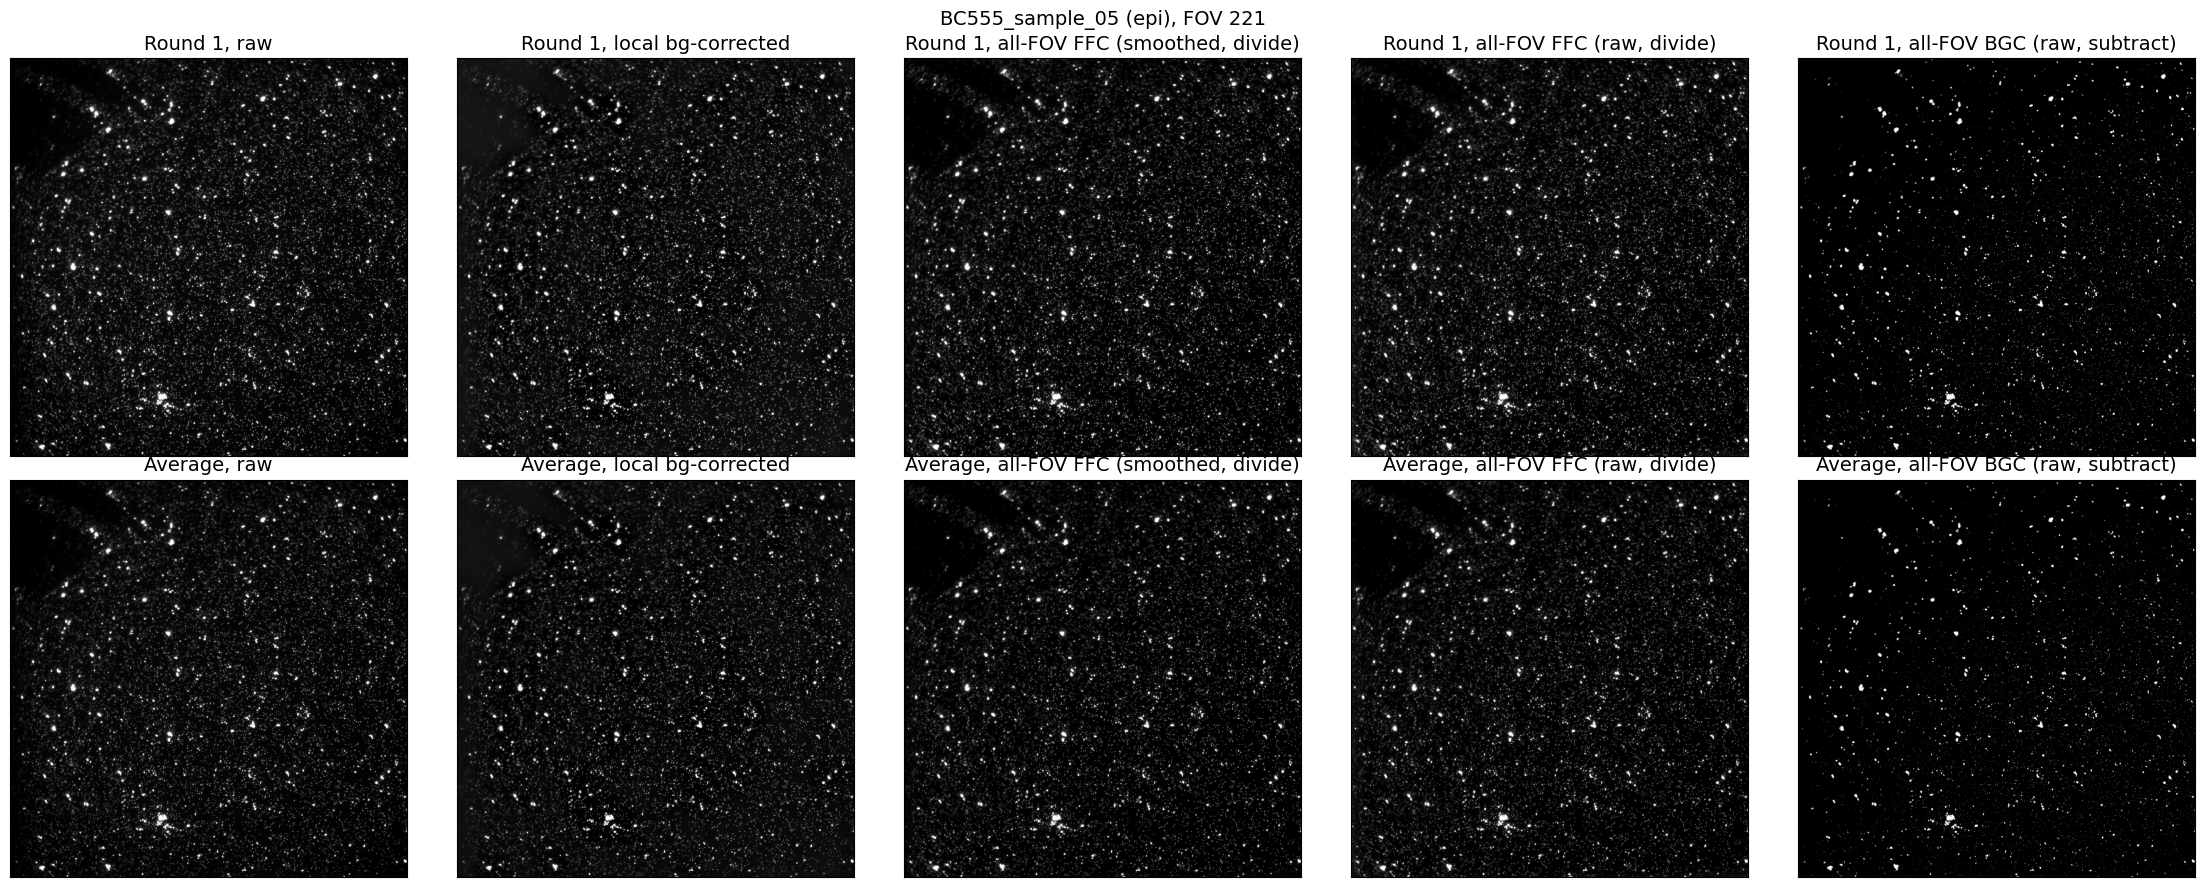

[epi] Saved: /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi/analysis/figures/test_bead_background_correction.raw_vs_corrected.png


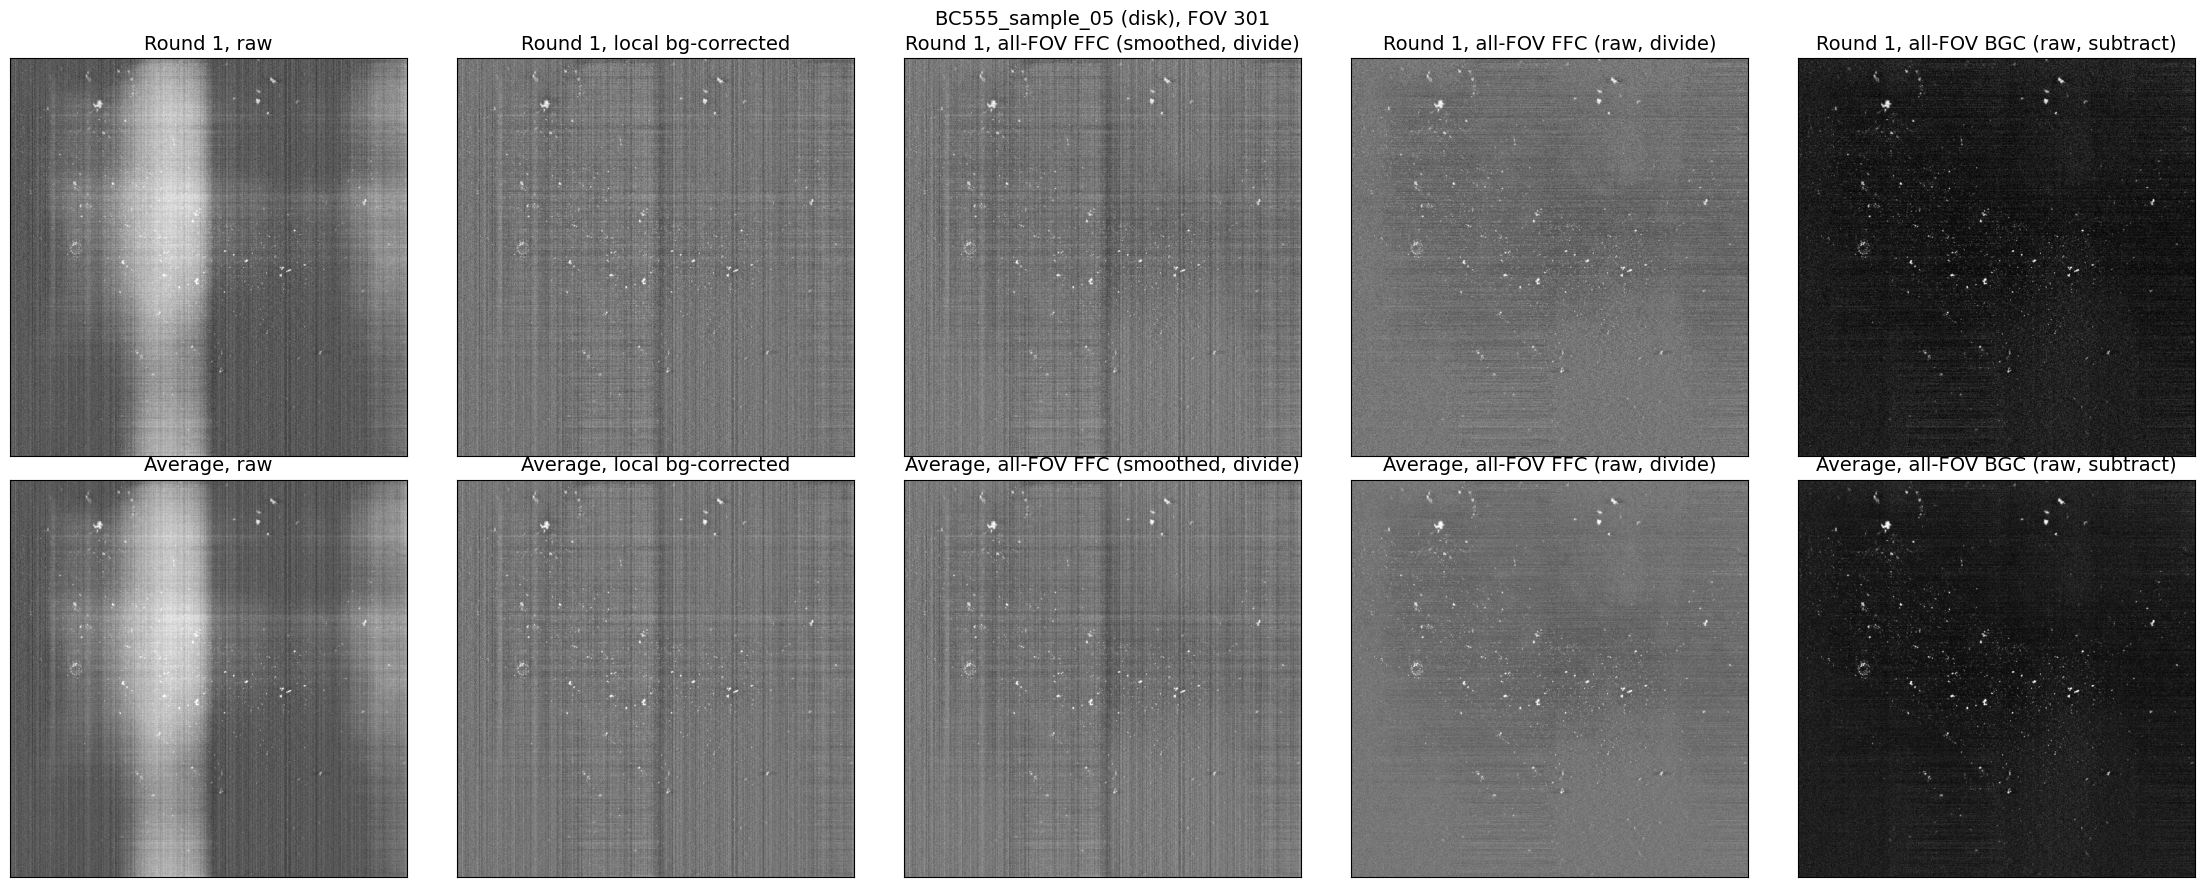

[disk] Saved: /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/disk/analysis/figures/test_bead_background_correction.raw_vs_corrected.png


In [9]:
PIPELINE_TITLES = {"raw": "raw", "bg_corrected": "local bg-corrected",
                    "ffc_corrected": "all-FOV FFC (smoothed, divide)",
                    "ffc_raw_corrected": "all-FOV FFC (raw, divide)",
                    "bgc_subtracted": "all-FOV BGC (raw, subtract)"}

for dataset_label, R in RESULTS.items():
    n_cols = len(PIPELINE_NAMES)
    fig, axes = plt.subplots(2, n_cols, figsize=(4.5 * n_cols, 9))
    for col, name in enumerate(PIPELINE_NAMES):
        vmin, vmax = np.percentile(R["pipelines"][name]["round1"], [1, 99])
        axes[0, col].imshow(R["pipelines"][name]["round1"], cmap="gray", vmin=vmin, vmax=vmax)
        axes[0, col].set_title(f"Round 1, {PIPELINE_TITLES[name]}", fontsize=PLOT_TITLE_FONTSIZE)
        axes[1, col].imshow(R["pipelines"][name]["average"], cmap="gray", vmin=vmin, vmax=vmax)
        axes[1, col].set_title(f"Average, {PIPELINE_TITLES[name]}", fontsize=PLOT_TITLE_FONTSIZE)
    for ax in axes.ravel():
        ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle(f"{R['dataset_geo']['sample_name']} ({dataset_label}), "
                 f"FOV {R['dataset_geo']['representative_fov']}", fontsize=PLOT_TITLE_FONTSIZE)
    fig.tight_layout()
    fig_path = R["dataset_geo"]["figures_dir"] / f"{NOTEBOOK_NAME}.raw_vs_corrected.png"
    fig.savefig(fig_path, dpi=150)
    plt.show()
    print(f"[{dataset_label}] Saved: {fig_path}")

## 9 — Does any correction recover more of the averaging benefit?

Same background-noise-std metric as `test_bead_round_averaging.ipynb`
Section 8 (background = round1-raw's own below-median pixels, same pixel
locations used for every image so the comparison is apples to apples),
computed for all five pipelines. If a background artifact was responsible
for disk's flat 0.95x result, correction should move `observed_ratio`
closer to `expected_ratio_if_independent_noise` for `disk` and leave `epi`
about where it already was. `ffc_raw_corrected` tests whether skipping the
field's Gaussian smoothing (Section 5) recovers more of that benefit than
the smoothed FFC did; `bgc_subtracted` tests whether the *subtractive* model
-- the physically appropriate one if the residual really is an additive
camera background level rather than a multiplicative illumination field --
recovers more still.

dataset          pipeline  n_rounds_averaged  background_std_round1  background_std_average  observed_ratio  expected_ratio_if_independent_noise
    epi               raw                 10                512.246                 456.380           1.122                                3.162
    epi      bg_corrected                 10                947.842                 845.201           1.121                                3.162
    epi     ffc_corrected                 10                594.207                 485.671           1.223                                3.162
    epi ffc_raw_corrected                 10                953.694                 819.852           1.163                                3.162
    epi    bgc_subtracted                 10                  3.052                   9.009           0.339                                3.162
   disk               raw                  2                  3.425                   3.591           0.954                       

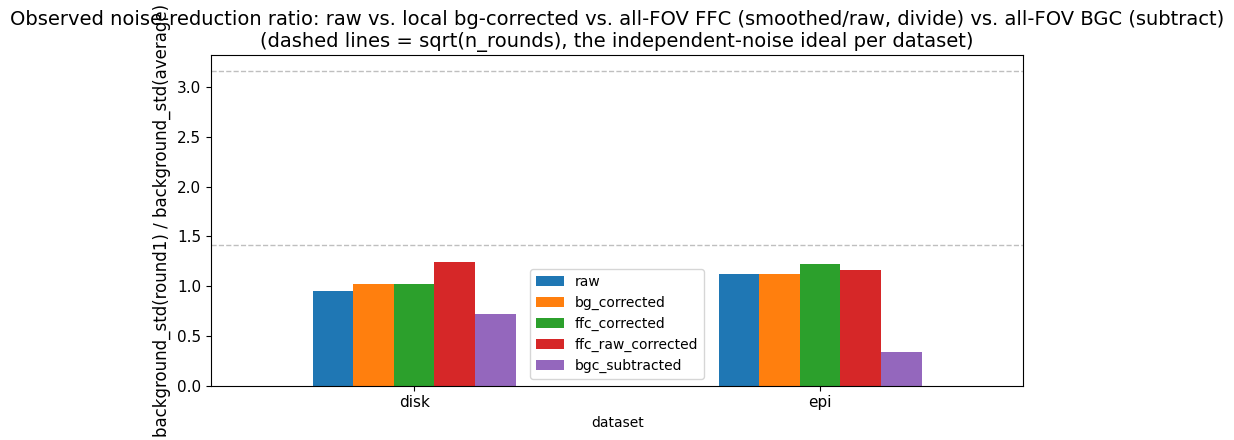

Saved: /n/home06/lsepulvedaduran/251225_LT027_saving_time/MERci/cache/test_bead_background_correction_comparison/test_bead_background_correction.noise_ratio_comparison.png


In [10]:
noise_rows = []
for dataset_label, R in RESULTS.items():
    n = R["n_rounds_averaged"]
    round1_raw = R["pipelines"]["raw"]["round1"]
    bg_mask = round1_raw < np.median(round1_raw)
    for name in PIPELINE_NAMES:
        std_before = float(np.std(R["pipelines"][name]["round1"][bg_mask]))
        std_after  = float(np.std(R["pipelines"][name]["average"][bg_mask]))
        noise_rows.append({
            "dataset": dataset_label, "pipeline": name, "n_rounds_averaged": n,
            "background_std_round1": std_before, "background_std_average": std_after,
            "observed_ratio": std_before / std_after, "expected_ratio_if_independent_noise": np.sqrt(n),
        })

noise_df = pd.DataFrame(noise_rows)
print(noise_df.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4.5))
pivot = noise_df.pivot(index="dataset", columns="pipeline", values="observed_ratio")[list(PIPELINE_NAMES)]
pivot.plot(kind="bar", ax=ax)
for dataset_label, R in RESULTS.items():
    ax.axhline(np.sqrt(R["n_rounds_averaged"]), color="gray", linestyle="--", linewidth=1, alpha=0.5)
ax.set_ylabel("background_std(round1) / background_std(average)", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_title("Observed noise-reduction ratio: raw vs. local bg-corrected vs. all-FOV FFC "
             "(smoothed/raw, divide) vs. all-FOV BGC (subtract)\n"
             "(dashed lines = sqrt(n_rounds), the independent-noise ideal per dataset)",
             fontsize=PLOT_TITLE_FONTSIZE)
ax.tick_params(axis="both", labelsize=PLOT_TICK_FONTSIZE)
ax.legend(fontsize=PLOT_LEGEND_FONTSIZE)
plt.setp(ax.get_xticklabels(), rotation=0)
fig.tight_layout()
fig_path = MERCI_DIR / "cache" / "test_bead_background_correction_comparison" / f"{NOTEBOOK_NAME}.noise_ratio_comparison.png"
fig_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(fig_path, dpi=150)
plt.show()
print(f"Saved: {fig_path}")